# Naked Planet Model
The goal of this excercise is to create an iterative simulation representing the temperature of the planet over time. The temperature of the planet is related to the energy in the planitary system. For simplicity, we are using a very basic model of the Earth where we assume that there is no atmosphere and that the Earth is covered in water.
With these basic assumptions, our model only needs to account for the energy entering the system as sunlight and the energy leaving the system as infrared (IR). The sunlight is given as $E_{incoming} = L \times \frac{(1-\alpha)}{4}$, where $L$ is the light energy hitting the Earth and $\alpha$ is the albedo of the planet. The IR is given as $E_{outgoing} = \epsilon \times \sigma \times T^4$, where $T$ is the temperature of the planet, $\epsilon$ is the emissivity of the Earth (here Earth is assumed to be a blackbody), and $\sigma$ is the Stefan-Boltzmann constant.

The problem statement gives the following initial conditions:

In [52]:
L = 1350                 # Watts/m2
albedo = 0.3
epsilon = 1
sigma = 5.67E-8          # W/m2 K4
initialTemp = 0          # K

With these initial conditions and equations, we can create some functions to use in our model:

In [53]:
def incomingSolar():
    return L * (1 - albedo) / 4

In [54]:
def outgoingIR(temp):
    return epsilon * sigma * pow(temp, 4)

In [55]:
def totalHeatFluxWatts(temp):
    return incomingSolar() - outgoingIR(temp)

We can see that the outgoing IR depends on the temperature of the Earth, and the temperature of the Earth will depend on how much energy is lost through emission. This is why we need to use an iterative model.
As this is an iterative model, we must choose the timestep and time period over which to run this.

In [56]:
timeStep = 10
simulationPeriod = 5000 # years (the simulation will run for at least this long)

In addition, the total heat flux gave us a result in watts, but we need to know the total energy in the system, so we must convert this to joules by multiplying the result by the number of steps in a year (we will ignore leap years for this simple model).

In [57]:
secondsPerYear = 60 * 60 * 24 * 365 # s/year

In [58]:
def totalHeatFluxJoules(temp):
    return totalHeatFluxWatts(temp) * secondsPerYear * timeStep

The last missing piece is the calculation for temperature. The temperature depends on the heat capacity of the planet. Since we are assuming that the planet is entirely made of water, we can calculate the heat capacity of each square meter of the planet's surface as the heat capacity of the column of water below. The heat capacity of water can be found online to be $4.184E6\frac{J}{Km^3}$, and the water column is given in the problem statement as 4000m

In [59]:
oceanDepth = 4000                                           # meters
heatCapacityCubicMLiquid = 4184000                           # J/m^3
heatCapacityBody = oceanDepth * heatCapacityCubicMLiquid    # J/m^2

We now have equations for the energy over each square meter of the Earth, and the heat capacity of each square meter of the Earth. For this simple model, we are treating the Earth as uniform, so we can simply divide the energy per square meter by the heat capacity per square meter to find the temperature.

In [60]:
def temperature(heat_content):
    return heat_content / heatCapacityBody

Finally, we have everything in place to simulate the naked planet model. We will use an iterative approach to accumulate energy for each step and calculate the temperature, and therefore outgoing IR, at each time step.

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [62]:
def simulate():
    # Initialize arrays
    steps = math.ceil(simulationPeriod / timeStep)
    times = np.arange(steps) * timeStep
    temps = np.empty(steps)
    heat_content = 0


    # Set first row (calculate initial heat content from initial temp)
    temps[0] = initialTemp
    heat_content = temps[0] * heatCapacityBody

    # Simulate
    for s in range(1, steps):
        heat_content += totalHeatFluxJoules(temps[s - 1])
        temps[s] = temperature(heat_content)

    
    return times, temps, heat_content


In [63]:
def plot(title='Naked Planet Model'):
    times, temps, heat_content = simulate()
    # Plot table
    plt.figure(figsize=(8,5))
    plt.plot(times, temps, marker='o', linestyle='-', color='b', label='Temperature vs Time')

    plt.title(title)
    plt.xlabel('Time (years)')
    plt.ylabel('Temperature (K)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.plot()
    print(f"Heat content: {heat_content:.2e} J/m^2")

Heat content: 4.25e+12 J/m^2


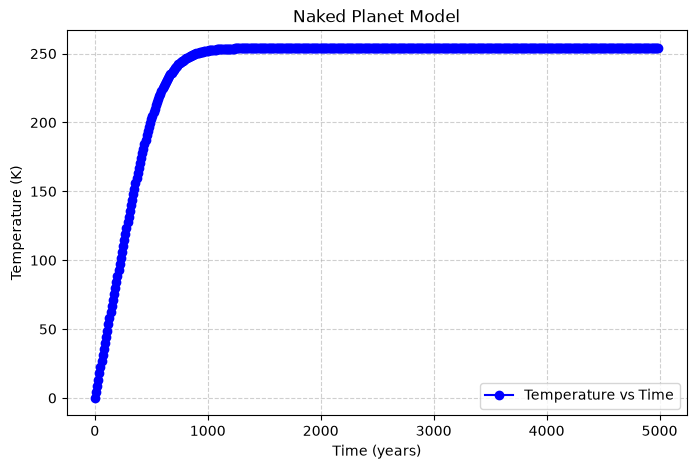

In [64]:
plot()

Now that we have the model up and running, we can simulate different planets.

Heat content: 4.25e+12 J/m^2


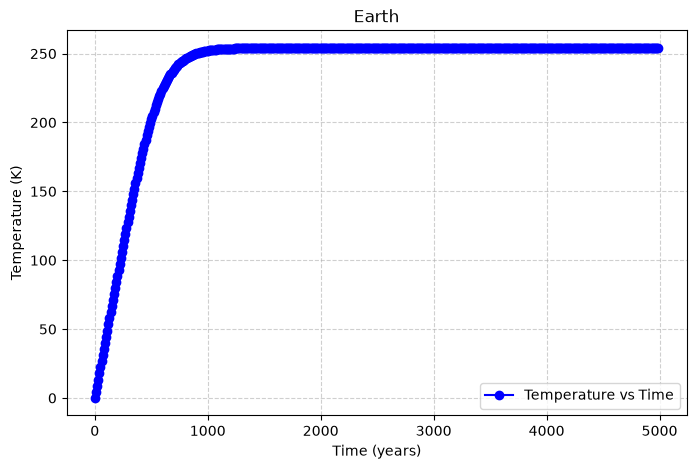

In [65]:
# Modern Earth
L = 1350                                                    # Watts/m2
albedo = 0.3
epsilon = 1
oceanDepth = 4000                                           # meters
heatCapacityCubicMLiquid = 4184000                           # J/m^3
heatCapacityBody = oceanDepth * heatCapacityCubicMLiquid    # J/m^2
timeStep = 10
simulationPeriod = 5000                                     # years 
plot('Earth')

Mars is very dry, so we will set the water depth to 1m (this represents the humidity of the soil rather than liquid water on Mars). It has an albedo of ~0.15, and it only receives ~590 W/m² of sunlight. We also need to adjust the timestep to ensure stability.

Heat content: 9.07e+08 J/m^2


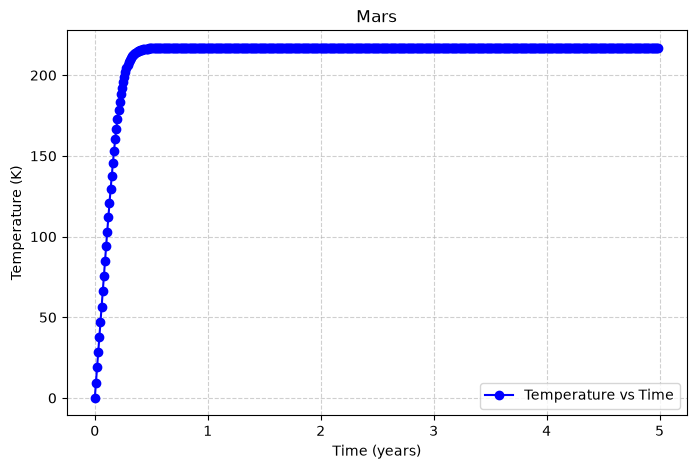

In [66]:
# Mars
L = 590                                                     # Watts/m2
albedo = 0.15
epsilon = 1
oceanDepth = 1                                              # meters
heatCapacityCubicMLiquid = 4184000                           # J/m^3
heatCapacityBody = oceanDepth * heatCapacityCubicMLiquid    # J/m^2
timeStep = 0.01
simulationPeriod = 5                                        # years 
plot("Mars")

Titan, a moon of Saturn, is made of methane. The heat capacity of methane is $1.46E6\frac{J}{m^3K}$. If we use a simple model of Titan with a uniform surface of 300m of methane, 14.8W/m² of sunlight, and an albedo of 0.265, we can find the temperature of this moon using our model.

Heat content: 3.65e+09 J/m^2


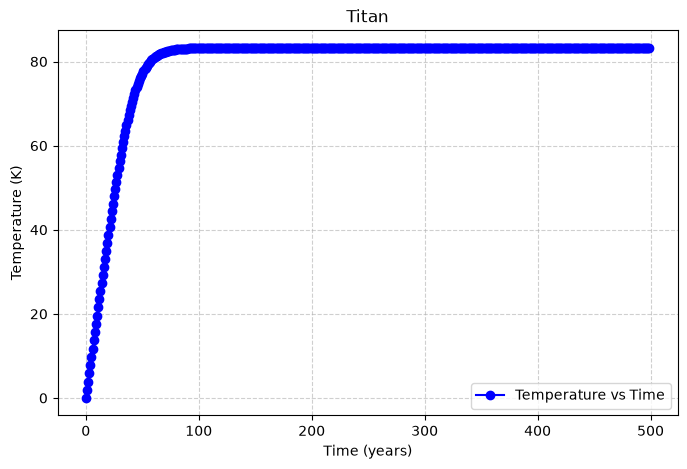

In [72]:
# Titan
L = 14.8                                                    # Watts/m2
albedo = 0.265
epsilon = 1
oceanDepth = 300                                            # meters
heatCapacityCubicMLiquid = 146000                           # J/m^3
heatCapacityBody = oceanDepth * heatCapacityCubicMLiquid    # J/m^2
timeStep = 1
simulationPeriod = 500                                      # years 
plot("Titan")

Using these models, we found Earth to be ~250K, Mars to be ~220K, and Titan to be ~85K. The true temperatures are 288K for the Earth, 208K for Mars, and 94K for Titan. Given the simplicity of the model, this is a good first approximation.